In [1]:
# === System & OS Utilities ===
import os
import math
import pickle
import sys
import warnings
warnings.filterwarnings("ignore")

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers

# === Data Handling ===
import numpy as np
import pandas as pd
import cv2

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# === Scikit-learn ===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

2025-09-03 17:05:57.940607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756919158.142455      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756919158.201491      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow version: 2.18.0
Keras version: 3.8.0
NumPy version: 1.26.4
Pandas version: 2.2.3
OpenCV version: 4.11.0
Matplotlib version: 3.7.2
Seaborn version: 0.12.2
Scikit-learn version: 1.2.2


In [3]:
#python version 3.11.11
#!python -m pip install tensorflow==2.18.0 keras==3.5.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.6.0.66 matplotlib==3.7.5 seaborn==0.12.2 scikit-learn==1.2.2

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [5]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 50
img_shape=(*IMG_SIZE,3)
dataset_path = r"/kaggle/input/ham10k-resized-masked-aug/HAM10000_organized_masked_out"
labels = sorted([d for d in os.listdir(dataset_path) 
                 if os.path.isdir(os.path.join(dataset_path, d))])
print("Class Names:", labels)

Class Names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [6]:
# Your Model and your Preprocess
# Only need to change here to load your desire model for the entire code
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.applications.resnet import ResNet50
model_name = "ResNet50"

In [7]:
def data_frame(path):
    class_paths = []
    classes = []

    for label in os.listdir(path):
        class_dir = os.path.join(path, label)
        if os.path.isdir(class_dir):  
            for image in os.listdir(class_dir):
                class_paths.append(os.path.join(class_dir, image))
                classes.append(label)

    df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return df

In [8]:
dataframe = data_frame(dataset_path)
# First split: 70% train, 30% temp (val + test)
train_dataframe, temp_dataframe = train_test_split(
    dataframe,
    test_size=0.3,
    random_state=42,
    stratify=dataframe['Class']
)

# Second split: 2/3 val, 1/3 test of the 30% => 20% val, 10% test overall
validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=1/3,
    random_state=42,
    stratify=temp_dataframe['Class']
)

print(f"Train size: {len(train_dataframe)}, Validation size: {len(validation_dataframe)}, Test size: {len(test_dataframe)}")

Train size: 32854, Validation size: 9387, Test size: 4694


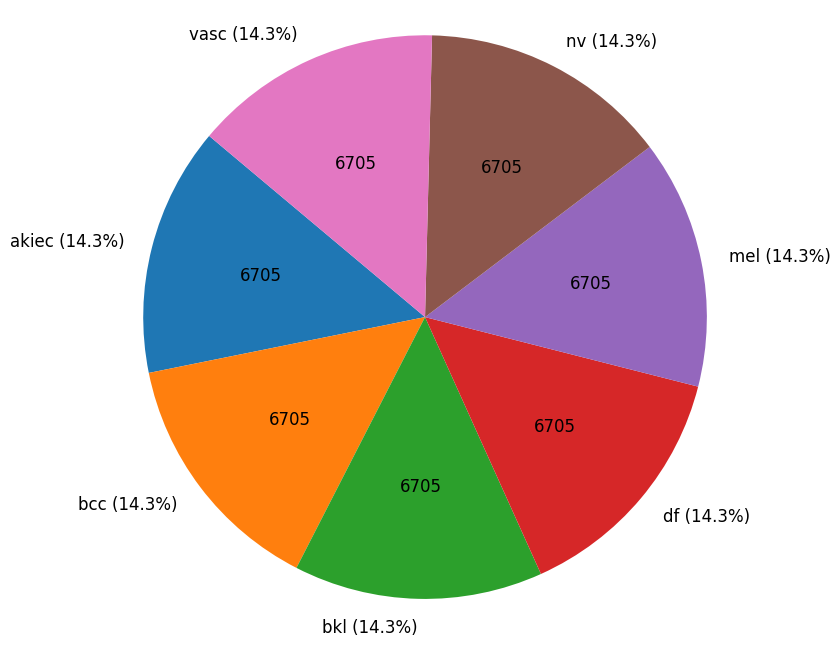

In [9]:
# Count occurrences in each DataFrame
train_counts = train_dataframe['Class'].value_counts()
val_counts = validation_dataframe['Class'].value_counts()
test_counts = test_dataframe['Class'].value_counts()

# Combine and sum the counts
total_counts = train_counts.add(val_counts, fill_value=0)
total_counts = total_counts.add(test_counts, fill_value=0)
total_counts = total_counts.sort_index()

# Prepare labels with percentages
total = total_counts.sum()
labels_with_percent = [f"{label} ({(count/total)*100:.1f}%)" for label, count in zip(total_counts.index, total_counts.values)]

# Define custom autopct function to show raw count
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_counts.values, labels=labels_with_percent, autopct=make_autopct(total_counts.values), startangle=140, textprops={'fontsize': 12})
plt.axis('equal')
plt.show()

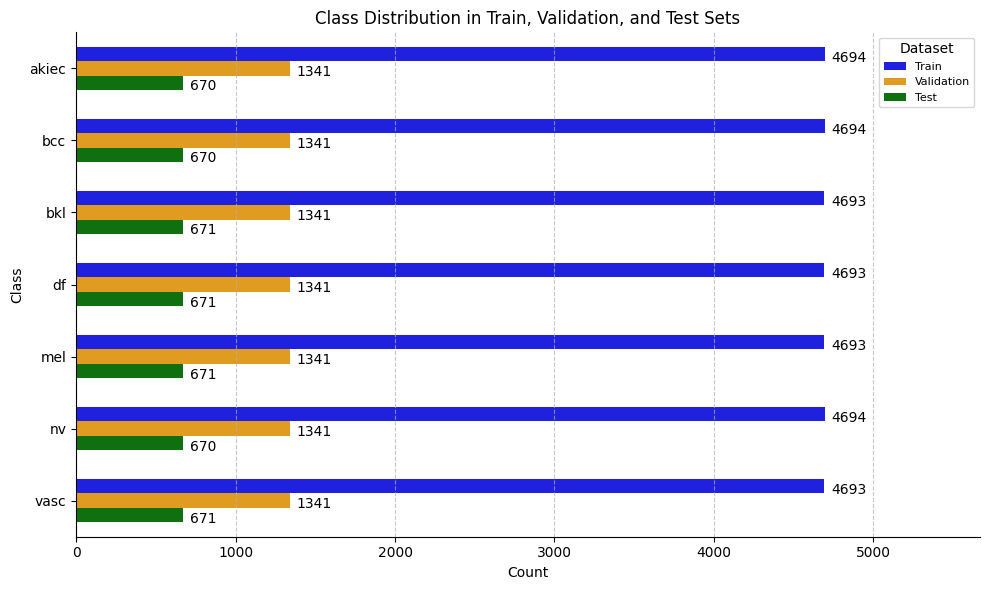

In [10]:
# Count occurrences of each class in train, validation, and test datasets
train_counts = train_dataframe['Class'].value_counts().sort_index()
val_counts = validation_dataframe['Class'].value_counts().sort_index()
test_counts = test_dataframe['Class'].value_counts().sort_index()

# Combine into a DataFrame with the index kept as a column
data_counts = pd.DataFrame({
    'Class': train_counts.index,
    'Train': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values
}).melt(id_vars='Class', var_name='Dataset', value_name='Count')

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Class', x='Count', hue='Dataset', data=data_counts, 
                 palette=['blue', 'orange', 'green'], orient='h', width=0.6)

# Add count labels to the right of the bars with slight downward offset
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.0 + 0.05),  # pushed slightly down
                ha='left', va='center', 
                fontsize=10, color='black', 
                xytext=(5, 0), textcoords='offset points')

# Remove borders (spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Dynamically set the x-axis limits with some extra space on the right
left, right = ax.get_xlim()  # Get current x-limits

# Set the new right limit with a 15% increase
right += (right - left) * 0.15  # Increase right by 15%

# Apply the new limits to the x-axis
ax.set_xlim(left, right)

# Add labels and title
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class Distribution in Train, Validation, and Test Sets")

# Move the legend
plt.legend(title="Dataset", loc='upper right', fontsize=8)

# Add grid only along x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tidy layout
plt.tight_layout()
plt.show()

In [11]:
def preprocess_image(image, clipLimit=0.02, tileGridSize=(8,8)):
    """
    CLAHE preprocessing that only applies enhancement inside non-black lesion mask.
    Works with Keras ImageDataGenerator's `preprocessing_function` (one image at a time).
    Returns float32 image (normalized by preprocess_input if available).
    """
    # Ensure uint8 in 0..255 for OpenCV CLAHE operations
    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255.0).astype(np.uint8)
        else:
            image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # lesion mask: non-black pixels
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    mask = gray > 0   # boolean (H, W)

    # convert to LAB and compute CLAHE on the full L channel
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    L = lab[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    L_clahe = clahe.apply(L)   # full 2D image

    # apply CLAHE result only inside mask (copy back)
    L_out = L.copy()
    L_out[mask] = L_clahe[mask]
    lab[:, :, 0] = L_out

    # convert back to RGB
    out_rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB).astype(np.float32)  # values 0..255
    out_rgb = preprocess_input(out_rgb) # model specific preprocess
    return out_rgb

In [12]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,  # CLAHE preprocessing
    rotation_range=180,          # lesions can be at any orientation
    zoom_range=0.15,             # up to ±15% zoom
    width_shift_range=0.10,      # up to 10% horizontal shift
    height_shift_range=0.10,     # up to 10% vertical shift
    shear_range=0.05,            # very small shear (avoid heavy distortion)
    horizontal_flip=True,        # horizontal flipping image
    vertical_flip=True,          # vertically flipping image
    brightness_range=[0.9, 1.1], # ±10% brightness variation
    fill_mode='constant',        # <<< use constant fill
    cval=0                       # <<< fill value (0 -> black)
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Class Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, shuffle=False, seed=42)

Found 32854 validated image filenames belonging to 7 classes.
Found 9387 validated image filenames belonging to 7 classes.
Found 4694 validated image filenames belonging to 7 classes.


In [13]:
def _denormalize_for_display(img):
    """
    Convert a preprocessed float image to uint8 for plt.imshow.
    Uses per-image min-max scaling so display is robust.
    """
    im = img.copy().astype(np.float32)
    im_min = float(np.min(im))
    im_max = float(np.max(im))
    if im_max - im_min < 1e-6:
        return np.zeros_like(im, dtype=np.uint8)
    im_out = (im - im_min) / (im_max - im_min)
    im_out = (im_out * 255.0).clip(0, 255).astype(np.uint8)
    return im_out


def show_from_generator(generator, n=5):
    """
    Fetch one batch from a Keras ImageDataGenerator (or Sequence) and show `n` images.
    - Make sure the generator was created AFTER you updated preprocess_image.
    """
    # Get a batch robustly
    try:
        batch = next(generator)
    except TypeError:
        batch = generator[0]
    except StopIteration:
        gen_iter = iter(generator)
        batch = next(gen_iter)

    # handle common batch formats
    if isinstance(batch, (tuple, list)):
        images, labels = batch[0], batch[1] if len(batch) > 1 else None
    elif isinstance(batch, dict):
        images = batch.get("images") or batch.get("x") or batch.get("inputs")
        labels = batch.get("labels") or batch.get("y")
    else:
        raise ValueError("Unsupported batch format from generator")

    images = np.asarray(images)
    n = min(n, len(images))
    plt.figure(figsize=(3 * n, 3))
    for i in range(n):
        img = images[i]
        disp = _denormalize_for_display(img)
        plt.subplot(1, n, i + 1)
        plt.imshow(disp)
        if labels is not None:
            lbl = np.argmax(labels[i]) if getattr(labels, "ndim", 0) > 1 else labels[i]
            plt.title(f"Label: {lbl}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

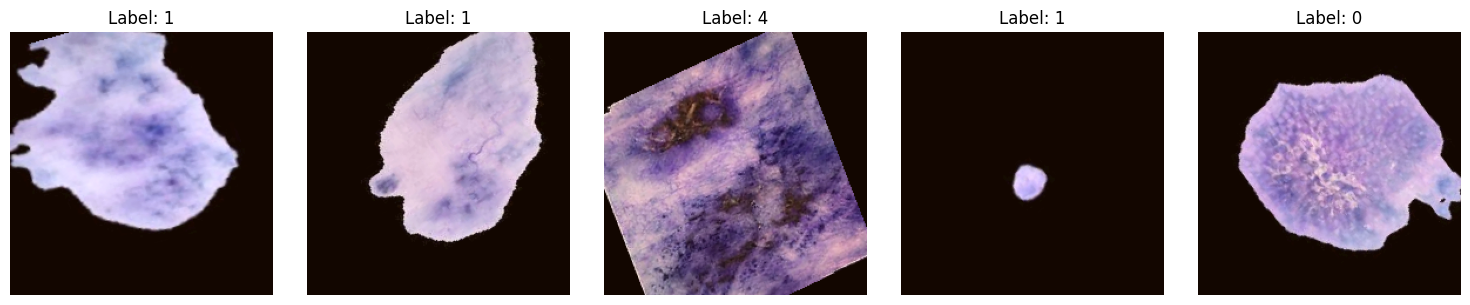

In [14]:
show_from_generator(train_data)

In [15]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="F1Score")
class F1Score(tf.keras.metrics.Metric):
    """
    Custom Keras metric to compute the F1 Score.
    The F1 score is the harmonic mean of precision and recall.
    """

    def __init__(self, name='f1_score', **kwargs):
        """
        Initializes the F1Score metric. 
        - Uses Keras' Precision and Recall metrics as intermediate steps.
        """
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()  # Precision metric
        self.recall = tf.keras.metrics.Recall()  # Recall metric

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Updates the state of the metric.
        - This method is called during training to update precision and recall.
        - The precision and recall states are updated based on true and predicted values.
        """
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        """
        Computes and returns the F1 score.
        - F1 score is calculated as the harmonic mean of precision and recall.
        - Prevents division by zero by adding a small epsilon value to the denominator.
        """
        p = self.precision.result()  # Get precision value
        r = self.recall.result()  # Get recall value
        return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())  # Calculate F1 score

    def reset_states(self):
        """
        Resets the states of the precision and recall metrics.
        - This is called at the beginning of each epoch.
        """
        self.precision.reset_states()  # Reset precision state
        self.recall.reset_states()  # Reset recall state


In [16]:
class RestoreBestValidationModel(Callback):
    """
    Custom Keras Callback to restore model weights from the best epoch based on validation accuracy.
    - Tracks the best validation accuracy during training.
    - Restores the model weights from the epoch with the best validation accuracy when training finishes.
    """
    
    def __init__(self):
        super(RestoreBestValidationModel, self).__init__()
        # Initialize best validation accuracy, epoch, and weights to track the best model
        self.best_val_acc = -1
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        """
        Callback function executed at the end of each epoch.
        - Compares the current validation accuracy with the best validation accuracy.
        - If the current validation accuracy is higher or tied but at a later epoch, updates the best model weights.
        """
        # Get validation accuracy from logs
        val_acc = logs.get('val_accuracy')
        
        if val_acc is not None:
            # Update the best validation accuracy and weights if the current one is better or at a later epoch
            if val_acc > self.best_val_acc or (val_acc == self.best_val_acc and epoch > self.best_epoch):
                self.best_val_acc = val_acc
                self.best_epoch = epoch
                self.best_weights = self.model.get_weights()  # Store the model's weights
                print(f"Model weights updated at epoch {epoch + 1} with val_accuracy: {val_acc:.4f}")

    def on_train_end(self, logs=None):
        """
        Callback function executed at the end of training.
        - Restores the model weights from the epoch with the best validation accuracy.
        """
        # If we found a better model during training, restore the best weights
        if self.best_weights is not None:
            print(f"Restoring model weights from best epoch {self.best_epoch + 1} with val_accuracy: {self.best_val_acc:.4f}")
            self.model.set_weights(self.best_weights)  # Set the weights back to the best model's weights

# Instantiate the callback
restore_best = RestoreBestValidationModel()


In [17]:
# ------------------------------
# CoordAttention (serializable)
# ------------------------------
@tf.keras.utils.register_keras_serializable(package="custom_layers")
class CoordAttention(layers.Layer):
    """
    CoordAttention block.
    - reduction: bottleneck factor for the shared transform.
    Behavior: pools along H and W separately, applies a shared conv, then generates two attention maps
    that are multiplied to the input (broadcasted).
    """
    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = int(reduction)

    def build(self, input_shape):
        _, H, W, C = input_shape
        C = int(C)
        self.C = C
        mid_channels = max(8, C // self.reduction)

        # shared 1x1 conv to reduce channels after concatenation
        self.conv1 = layers.Conv2D(mid_channels, kernel_size=1, padding="same", use_bias=True, activation="relu", name=self.name + "_conv1")
        self.bn = layers.BatchNormalization(name=self.name + "_bn")

        # projectors to restore channel dimension for H and W attention
        self.conv_h = layers.Conv2D(C, kernel_size=1, padding="same", use_bias=True, activation="sigmoid", name=self.name + "_conv_h")
        self.conv_w = layers.Conv2D(C, kernel_size=1, padding="same", use_bias=True, activation="sigmoid", name=self.name + "_conv_w")

        super().build(input_shape)

    def call(self, inputs):
        # inputs: (B, H, W, C)
        x = inputs
        # pooled along width -> shape (B, H, 1, C)
        x_h = tf.reduce_mean(x, axis=2, keepdims=True)
        # pooled along height -> shape (B, 1, W, C)
        x_w = tf.reduce_mean(x, axis=1, keepdims=True)

        # transpose x_w to (B, W, 1, C) so we can concat along the "height-like" axis
        x_w_perm = tf.transpose(x_w, perm=[0, 2, 1, 3])

        # concat -> (B, H+W, 1, C)
        x_cat = tf.concat([x_h, x_w_perm], axis=1)

        # shared transform
        x_cat = self.conv1(x_cat)
        x_cat = self.bn(x_cat)

        # split back to H and W parts
        H_len = tf.shape(x_h)[1]
        W_len = tf.shape(x_w_perm)[1]
        x_h_part, x_w_part = tf.split(x_cat, [H_len, W_len], axis=1)

        # restore original orientation for x_w (transpose back)
        x_w_part = tf.transpose(x_w_part, perm=[0, 2, 1, 3])  # (B, 1, W, mid)

        # project to attention maps
        a_h = self.conv_h(x_h_part)  # shape (B, H, 1, C)
        a_w = self.conv_w(x_w_part)  # shape (B, 1, W, C)

        # broadcast to (B, H, W, C) and multiply
        out = inputs * a_h * a_w
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg

In [18]:
# Note: This Layer is not used.. I just made it to use in future 
# ------------------------------------
# MHSAHead: small multi-head attention head
# ------------------------------------
@tf.keras.utils.register_keras_serializable(package="custom_layers")
class MHSAHead(layers.Layer):
    """
    Small classification head using MultiHeadAttention over spatial tokens.
    - n_heads: number of attention heads
    - key_dim: per-head key dimension
    - mlp_dim: dense dimension after pooling
    - dropout: dropout rate applied after MLP
    This layer returns a (B, mlp_dim) feature vector.
    """
    def __init__(self, n_heads=4, key_dim=32, mlp_dim=128, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.n_heads = int(n_heads)
        self.key_dim = int(key_dim)
        self.mlp_dim = int(mlp_dim)
        self.dropout_rate = float(dropout)

        # layers will be created in build()
        self.norm = layers.LayerNormalization(name=self.name + "_ln")
        self.mha = None
        self.pool = layers.GlobalAveragePooling1D(name=self.name + "_gap1d")
        self.dense = None
        self.dropout = None

    def build(self, input_shape):
        # input_shape: (B, H, W, C)
        _, H, W, C = input_shape
        self.C = int(C)
        self.mha = layers.MultiHeadAttention(num_heads=self.n_heads, key_dim=self.key_dim, name=self.name + "_mha")
        self.dense = layers.Dense(self.mlp_dim, activation="relu", name=self.name + "_mlp")
        if self.dropout_rate > 0.0:
            self.dropout = layers.Dropout(self.dropout_rate, name=self.name + "_dropout")
        super().build(input_shape)

    def call(self, inputs, training=None):
        # flatten spatial dims to tokens: (B, N, C) where N = H*W
        shape = tf.shape(inputs)
        B = shape[0]
        H = shape[1]
        W = shape[2]
        N = H * W

        x = tf.reshape(inputs, (B, N, self.C))  # (B, N, C)
        x = self.norm(x)
        # self-attention (queries=keys=values)
        x = self.mha(x, x, x, training=training)  # (B, N, C')
        # pool across tokens to get a vector
        x = self.pool(x)  # (B, C')
        x = self.dense(x)  # (B, mlp_dim)
        if self.dropout is not None:
            x = self.dropout(x, training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"n_heads": self.n_heads, "key_dim": self.key_dim, "mlp_dim": self.mlp_dim, "dropout": self.dropout_rate})
        return cfg

In [19]:
# Base model
base_model = eval(f"{model_name}(weights='imagenet', include_top=False, input_shape=img_shape, pooling=None)")

# Attach CoordAttention + MHSA head to the final feature map
x = base_model.output                  # (batch, h, w, c)

#--------------------------------------------------------------------------
# IMPORTANT: Don't use proposed attention layers for comparison
#x = CoordAttention(reduction=32)(x)    # replace SEBlock with CoordAttention
#x = MHSAHead(n_heads=4, key_dim=32, mlp_dim=128, dropout=0.0)(x)  # small MHSA head -> returns (B, mlp_dim)
#--------------------------------------------------------------------------
#--------------------------------------------------------------------------
# IMPORTANT: if not use MHSAHead then uncomment below global average pooling
# If used MHSAHead then comment out this global average pooling
x = GlobalAveragePooling2D()(x)        # -> (batch, c)
#--------------------------------------------------------------------------

# Continue classification
x = Dropout(0.30)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=L1L2(l1=1e-4, l2=1e-3))(x)
x = Dropout(0.25)(x)
x = layers.Dense(len(labels), activation='softmax')(x)

# Define the complete model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# unfreeze all layers
base_model.trainable = True

# Compile the model
model.compile(optimizer=Adamax(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall'),
                       F1Score(),         # our fallback micro-F1
                       AUC(name='auc')])

# Print the model summary to check the architecture.
model.summary()

I0000 00:00:1756919259.847942      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 23,797,767 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [20]:
history = model.fit(train_data,
                 epochs=EPOCH,             
                 validation_data=validation_data,
                 callbacks=[restore_best],
                 shuffle= False)

Epoch 1/50


I0000 00:00:1756919320.255783      63 service.cc:148] XLA service 0x7afe6c0ae320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756919320.256564      63 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1756919324.907830      63 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756919348.774128      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1027/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.6021 - auc: 0.8955 - f1_score: 0.5604 - loss: 1.9240 - precision: 0.7560 - recall: 0.4515Model weights updated at epoch 1 with val_accuracy: 0.7361
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 907s 803ms/step - accuracy: 0.6022 - auc: 0.8955 - f1_score: 0.5605 - loss: 1.9237 - precision: 0.7561 - recall: 0.4516 - val_accuracy: 0.7361 - val_auc: 0.9476 - val_f1_score: 0.7337 - val_loss: 1.3930 - val_precision: 0.7743 - val_recall: 0.6971
Epoch 2/50
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.7681 - auc: 0.9662 - f1_score: 0.7611 - loss: 1.1300 - precision: 0.8292 - recall: 0.7033Model weights updated at epoch 2 with val_accuracy: 0.7713
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 688s 670ms/step - accuracy: 0.7681 - auc: 0.9662 - f1_score: 0.7611 - loss: 1.1299 - precision: 0.8292 - recall: 0.7033 - val_accuracy: 0.7713 - val_auc: 0.9690 - val_f1_score: 0.7659 - val_loss: 0.9278 - val_precision: 0.8261 - val_recall: 0.7139
Epoch 3/50
1027/1

In [21]:
model.save(f"{model_name}_trained.keras") 

In [22]:
model = load_model(f"{model_name}_trained.keras")  

In [23]:
# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [24]:
# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [25]:
epochs = range(1, len(history['loss']) + 1)

# Training and validation metrics
tr_loss = history['loss']
val_loss = history['val_loss']
tr_acc = history['accuracy']
val_acc = history['val_accuracy']
tr_precision = history['precision']
val_precision = history['val_precision']
tr_auc = history['auc']
val_auc = history['val_auc']
tr_f1 = history['f1_score']
val_f1 = history['val_f1_score']

In [26]:
def print_best_metrics(metric_name, train, val):
    best_epoch = np.argmax(val) + 1
    print(f"📌 Best {metric_name} at epoch {best_epoch}:")
    print(f"   - Train {metric_name}: {abs(train[best_epoch - 1]):.4f}")
    print(f"   - Val {metric_name}:   {abs(val[best_epoch - 1]):.4f}\n")

print_best_metrics("Accuracy", tr_acc, val_acc)
print_best_metrics("Precision", tr_precision, val_precision)
print_best_metrics("AUC", tr_auc, val_auc)
print_best_metrics("F1 Score", tr_f1, val_f1)
print_best_metrics("Loss", [-x for x in tr_loss], [-x for x in val_loss])  # inverted for max-based search

📌 Best Accuracy at epoch 33:
   - Train Accuracy: 0.9778
   - Val Accuracy:   0.9728

📌 Best Precision at epoch 33:
   - Train Precision: 0.9790
   - Val Precision:   0.9736

📌 Best AUC at epoch 33:
   - Train AUC: 0.9992
   - Val AUC:   0.9987

📌 Best F1 Score at epoch 33:
   - Train F1 Score: 0.9779
   - Val F1 Score:   0.9728

📌 Best Loss at epoch 33:
   - Train Loss: 0.0863
   - Val Loss:   0.0995



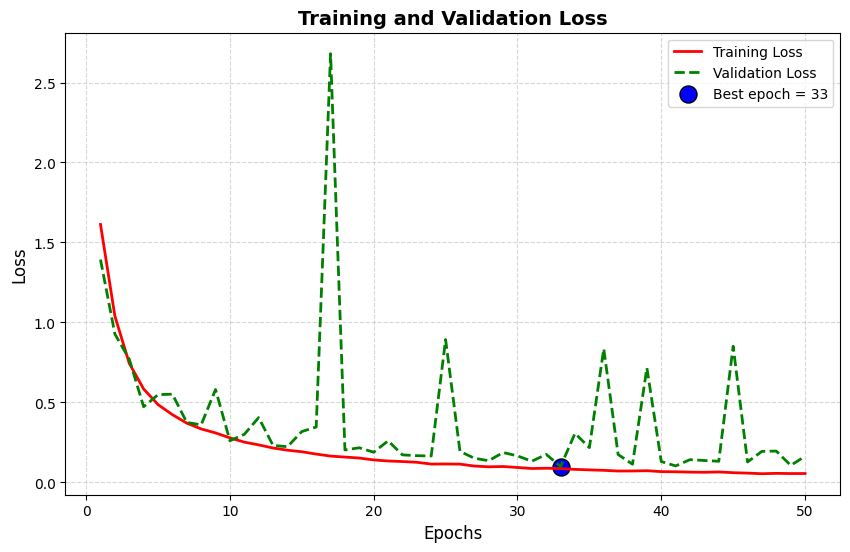

In [27]:
best_epoch_loss = np.argmin(val_loss)
best_val_loss = val_loss[best_epoch_loss]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_loss, color='red', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, color='green', label='Validation Loss', linestyle='--', linewidth=2)
plt.scatter(best_epoch_loss + 1, best_val_loss, s=150, c='blue',
            label=f'Best epoch = {best_epoch_loss + 1}', edgecolors='black')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

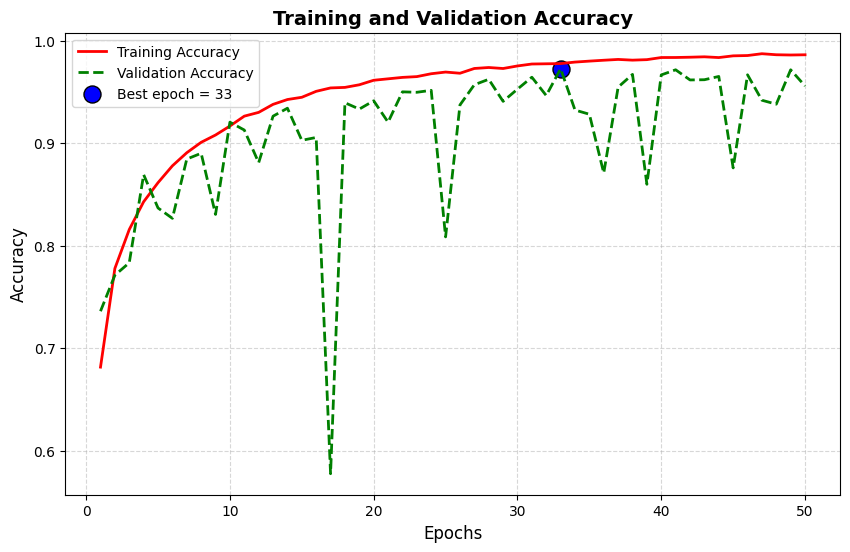

In [28]:
best_epoch_acc = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch_acc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, color='red', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='green', label='Validation Accuracy', linestyle='--', linewidth=2)
plt.scatter(best_epoch_acc + 1, best_val_acc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_acc + 1}', edgecolors='black')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


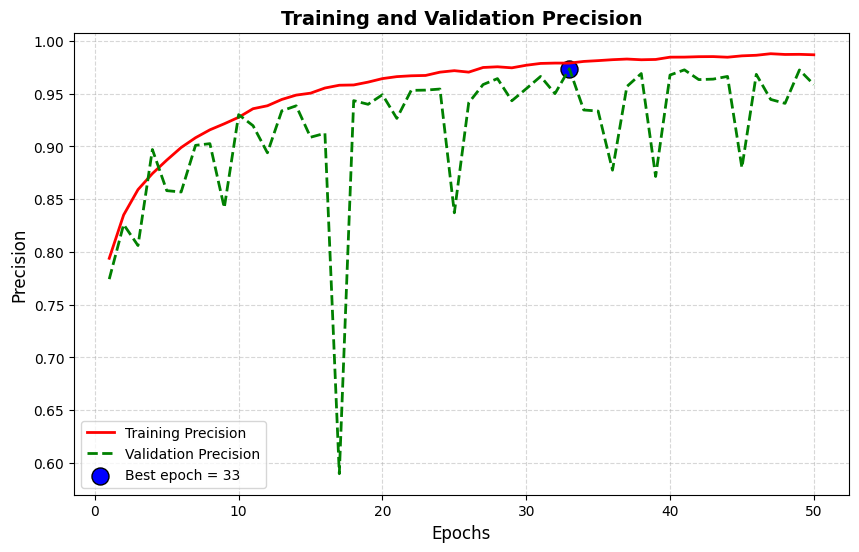

In [29]:
best_epoch_prec = np.argmax(val_precision)
best_val_prec = val_precision[best_epoch_prec]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_precision, color='red', label='Training Precision', linewidth=2)
plt.plot(epochs, val_precision, color='green', label='Validation Precision', linestyle='--', linewidth=2)
plt.scatter(best_epoch_prec + 1, best_val_prec, s=150, c='blue',
            label=f'Best epoch = {best_epoch_prec + 1}', edgecolors='black')
plt.title('Training and Validation Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


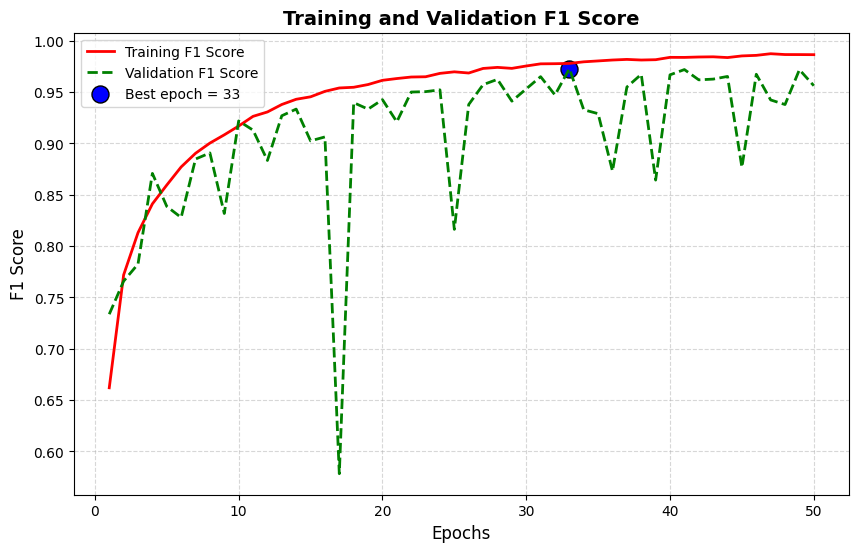

In [30]:
best_epoch_f1 = np.argmax(val_f1)
best_val_f1 = val_f1[best_epoch_f1]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_f1, color='red', label='Training F1 Score', linewidth=2)
plt.plot(epochs, val_f1, color='green', label='Validation F1 Score', linestyle='--', linewidth=2)
plt.scatter(best_epoch_f1 + 1, best_val_f1, s=150, c='blue',
            label=f'Best epoch = {best_epoch_f1 + 1}', edgecolors='black')
plt.title('Training and Validation F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

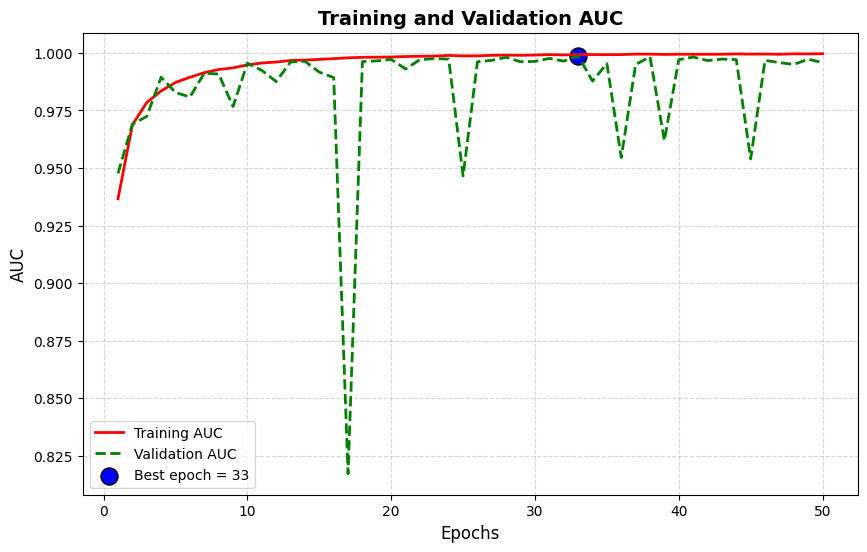

In [31]:
best_epoch_auc = np.argmax(val_auc)
best_val_auc = val_auc[best_epoch_auc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_auc, color='red', label='Training AUC', linewidth=2)
plt.plot(epochs, val_auc, color='green', label='Validation AUC', linestyle='--', linewidth=2)
plt.scatter(best_epoch_auc + 1, best_val_auc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_auc + 1}', edgecolors='black')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [32]:
def evaluate_model(model, test_data, labels, model_name, test_dataframe, batch_size=BATCH_SIZE):
    """
    Evaluate a trained Keras model using a test data generator.

    Args:
        model (Model): Trained Keras model.
        test_data (Iterator): A Keras data generator for testing.
        labels (List[str]): Class label names.
        model_name (str): Name of the model (for display).
        test_dataframe (pd.DataFrame): DataFrame with test samples (for step calculation).
        batch_size (int): Batch size used in the test_data generator.

    Returns:
        Tuple[dict, dict]: 
            - Dictionary containing accuracy, precision, recall, F1 score, and AUC.
            - Dictionary of AUC curve data {class_label: (fpr, tpr)} for ROC plotting.
    """

    # Calculate steps needed for full evaluation
    steps = math.ceil(len(test_dataframe) / batch_size)

    y_true = []
    y_pred = []
    y_probs = []

    # Loop through batches and collect predictions and true labels
    for _ in tqdm(range(steps), desc=f"Evaluating {model_name}"):
        images, labels_batch = next(test_data)

        preds = model.predict(images, verbose=0)            # Predicted probabilities
        y_probs.extend(preds)                               # Save for AUC

        y_pred.extend(np.argmax(preds, axis=-1))            # Predicted class indices
        y_true.extend(np.argmax(labels_batch, axis=-1))     # True class indices

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    # Calculate performance metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    try:
        auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
    except ValueError:
        auc = float('nan')

    # Generate classification report
    report = classification_report(y_true, y_pred, target_names=labels)

    # Print summary metrics
    print(f"--- {model_name} ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}\n")
    print("Classification Report:\n")
    print(report)

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        annot_kws={'size': 14}, cbar=True, linewidths=0.5, linecolor='gray',
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, rotation=45 if len(labels) > 10 else 0)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Compute ROC curve data per class
    auc_curve_data = {}
    try:
        for i, label in enumerate(labels):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
            auc_curve_data[label] = (fpr, tpr)
    except Exception:
        auc_curve_data = {}

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    }, auc_curve_data


Evaluating ResNet50: 100%|██████████| 147/147 [01:30<00:00,  1.63it/s]


--- ResNet50 ---
Accuracy : 0.9695
Precision: 0.9703
Recall   : 0.9695
F1 Score : 0.9695
AUC      : 0.9982

Classification Report:

              precision    recall  f1-score   support

       akiec       0.99      0.99      0.99       670
         bcc       0.99      0.98      0.98       670
         bkl       0.94      0.97      0.95       671
          df       1.00      1.00      1.00       671
         mel       0.98      0.90      0.94       671
          nv       0.91      0.96      0.93       670
        vasc       1.00      1.00      1.00       671

    accuracy                           0.97      4694
   macro avg       0.97      0.97      0.97      4694
weighted avg       0.97      0.97      0.97      4694



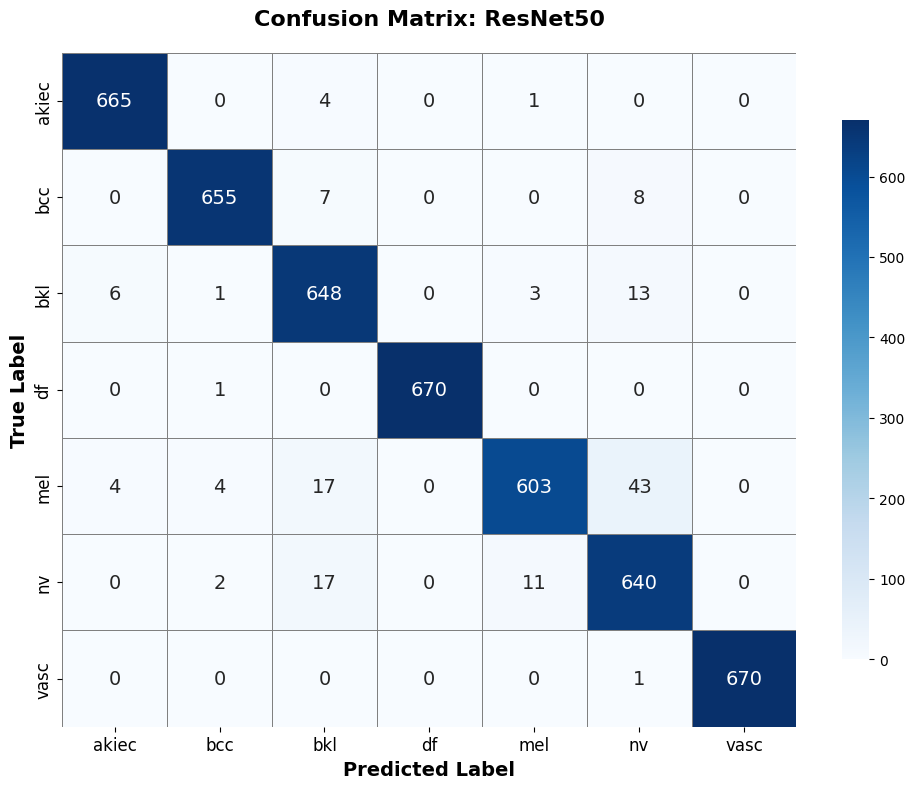

In [33]:
results, auc_curve_data = evaluate_model(model, test_data, labels, f"{model_name}", test_dataframe)

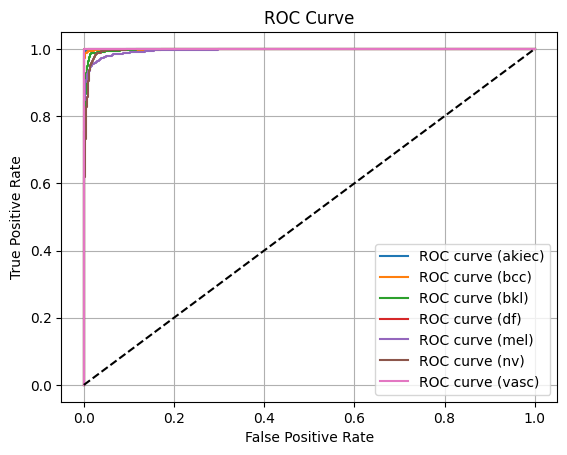

In [34]:
# Plotting the ROC curve
for label, (fpr, tpr) in auc_curve_data.items():
    plt.plot(fpr, tpr, label=f'ROC curve ({label})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

----------------
Bootstrap 95% Confidence interval


In [35]:
# -----------------------------
# Parameters
# -----------------------------
B = 1000                # number of bootstrap samples
RNG_SEED = 42

# 1) Get predictions and true labels
probs = model.predict(test_data, verbose=1)      # shape (N, num_classes)
y_true = np.asarray(test_data.classes)           # integer labels shape (N,)
num_classes = probs.shape[1]
y_pred = np.argmax(probs, axis=1)

# Point estimates
point_accuracy = accuracy_score(y_true, y_pred)
point_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
point_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
point_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
try:
    y_true_onehot = np.eye(num_classes)[y_true]
    point_auc = roc_auc_score(y_true_onehot, probs, multi_class='ovr', average='macro')
except Exception:
    point_auc = np.nan

147/147 ━━━━━━━━━━━━━━━━━━━━ 37s 218ms/step


In [36]:
# 2) Bootstrap
rng = np.random.RandomState(RNG_SEED)
metrics_boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "auc"]}
N = len(y_true)

for i in tqdm(range(B), desc="Bootstrap samples"):
    idx = rng.randint(0, N, size=N)   # sample with replacement
    y_true_b, y_pred_b, probs_b = y_true[idx], y_pred[idx], probs[idx]

    metrics_boot["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    metrics_boot["precision"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["recall"].append(recall_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["f1"].append(f1_score(y_true_b, y_pred_b, average='macro', zero_division=0))

    try:
        y_true_b_onehot = np.eye(num_classes)[y_true_b]
        auc_b = roc_auc_score(y_true_b_onehot, probs_b, multi_class='ovr', average='macro')
    except Exception:
        auc_b = np.nan
    metrics_boot["auc"].append(auc_b)

# Convert lists to arrays
for k in metrics_boot:
    metrics_boot[k] = np.array(metrics_boot[k], dtype=np.float32)

Bootstrap samples: 100%|██████████| 1000/1000 [00:20<00:00, 49.18it/s]


In [37]:
# 3) Compute 95% CI
def ci95(arr):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (np.nan, np.nan)
    return np.percentile(arr, [2.5, 97.5])

results = []
for name, point in [
    ("accuracy", point_accuracy),
    ("precision", point_precision),
    ("recall", point_recall),
    ("f1", point_f1),
    ("auc", point_auc)
]:
    lo, hi = ci95(metrics_boot[name])
    results.append({
        "metric": name,
        "point_estimate": point,
        "ci_lower": lo,
        "ci_upper": hi,
        "n_boot_valid": int(np.sum(~np.isnan(metrics_boot[name])))
    })

df_results = pd.DataFrame(results).set_index("metric")
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results)

           point_estimate  ci_lower  ci_upper  n_boot_valid
metric                                                     
accuracy           0.9695    0.9646    0.9744          1000
precision          0.9702    0.9654    0.9749          1000
recall             0.9695    0.9646    0.9744          1000
f1                 0.9695    0.9647    0.9743          1000
auc                0.9982    0.9976    0.9988          1000


In [38]:
def plot_bootstrap_metrics(metrics_boot, df_results, n_cols=3, figsize_per_plot=(5, 4),
                           w_pad=0.6, h_pad=1.5, shift_factor=0.5):
    """
    Plot bootstrap metric distributions.

    Args:
        metrics_boot: dict of metric -> bootstrap array
        df_results: DataFrame with point estimates and CIs
        n_cols: 
            >0 -> number of columns for grid layout
             0 -> plot each metric separately (one figure per metric)
        figsize_per_plot: (width, height) per subplot
        w_pad: horizontal gap between subplots (grid mode only)
        h_pad: vertical gap between subplots (grid mode only)
        shift_factor: how much to center last row if not full (grid mode only)
    """

    metrics = list(metrics_boot.keys())
    n_metrics = len(metrics)

    # --------------------
    # Single-plot mode
    # --------------------
    if n_cols == 0:
        for metric in metrics:
            vals = metrics_boot[metric]
            vals_nonan = vals[~np.isnan(vals)]

            fig, ax = plt.subplots(figsize=figsize_per_plot)
            ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
            ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
            ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
            ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

            ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
            ax.legend()
            plt.tight_layout()
            plt.show()
        return  # done

    # --------------------
    # Grid mode
    # --------------------
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_plot[0]*n_cols,
                                      figsize_per_plot[1]*n_rows))
    axes = np.array(axes).reshape(-1)  # flatten

    for i, metric in enumerate(metrics):
        ax = axes[i]
        vals = metrics_boot[metric]
        vals_nonan = vals[~np.isnan(vals)]

        ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
        ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
        ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
        ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

        ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
        ax.legend()

        # 🔹 Format x-axis ticks to 2 decimal places
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))

    # remove unused axes
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    # ---- Center last row if it's not full ----
    last_row_count = n_metrics % n_cols
    if last_row_count != 0:
        empty_slots = n_cols - last_row_count
        last_row_axes = axes[n_cols*(n_rows-1):n_cols*(n_rows-1)+last_row_count]

        for ax in last_row_axes:
            pos = ax.get_position()
            shift = (empty_slots / n_cols) * shift_factor
            pos_new = [pos.x0 + shift, pos.y0, pos.width, pos.height]
            ax.set_position(pos_new)

    plt.tight_layout(pad=1.0, w_pad=w_pad, h_pad=h_pad)
    plt.show()

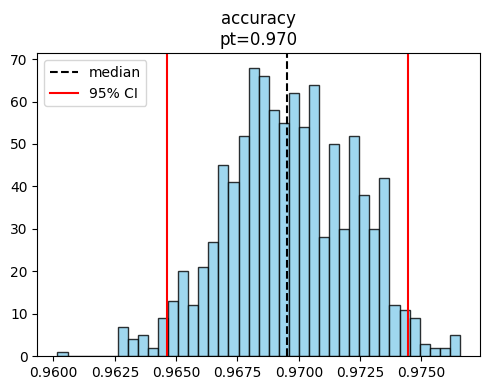

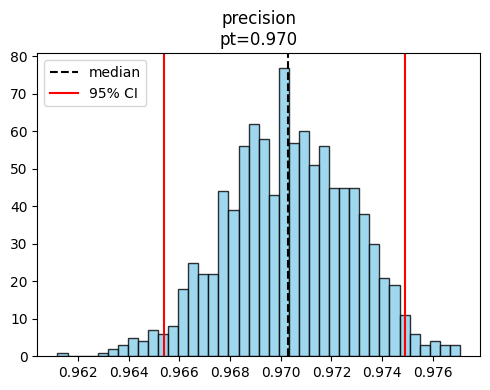

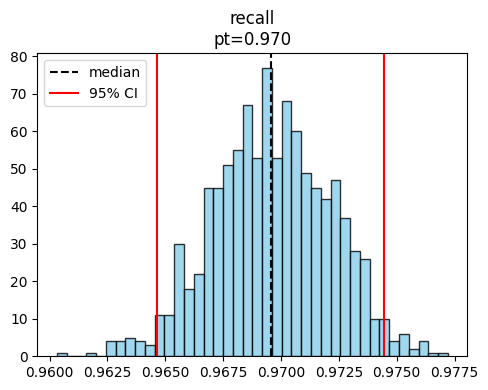

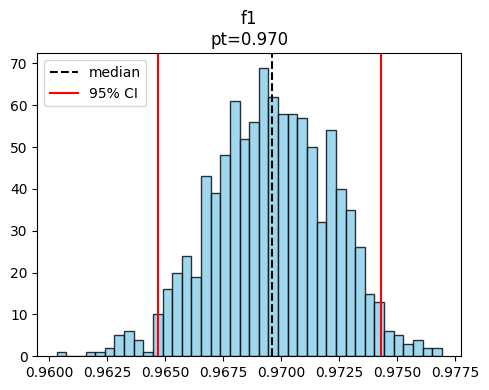

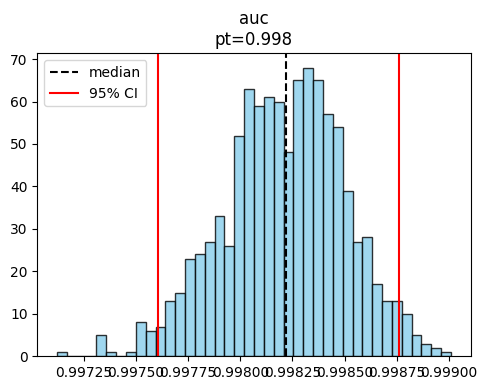

In [39]:
plot_bootstrap_metrics(
    metrics_boot, 
    df_results, 
    n_cols=0,        # number of columns in grid (set 0 for separate plots, 2 or 3 for grid)
    w_pad=0.5,       # horizontal space between columns (increase -> wider gap)
    h_pad=1.0,       # vertical space between rows (increase -> taller gap)
    shift_factor=0.0 # how much to horizontally shift last-row plots for centering
)


--------------------
Gradcam ++ (more advance visualization than previous version of mine)

In [40]:
# -----------------------
# Utility: find a suitable conv layer (last one)
# -----------------------
def find_last_conv_layer(model):
    # prefer layers with 'conv' in name, fallback to any 4D output layer
    for layer in reversed(model.layers):
        out_shape = getattr(layer, "output_shape", None)
        if out_shape is None:
            continue
        # output shape may be (None, H, W, C) or list
        try:
            if isinstance(out_shape, (list, tuple)) and len(out_shape) >= 4:
                if len(out_shape) == 4 and out_shape[1] is not None:
                    if "conv" in layer.name.lower():
                        return layer.name
        except Exception:
            pass

    # fallback: any layer with rank 4 output (H,W,C)
    for layer in reversed(model.layers):
        out_shape = getattr(layer, "output_shape", None)
        if out_shape is None:
            continue
        try:
            if len(out_shape) == 4:
                return layer.name
        except Exception:
            pass
            
    # hard fallback: any layer with cov in it
    for layer in reversed(model.layers):
        if "conv" in layer.name.lower():
            print("Warning..! Using last cov layer but it's not a 4D conv-like layer.!")
            return layer.name

    raise ValueError("Could not find a conv-like layer in the model. Please pass layer_name manually.")

In [41]:
# -----------------------
# Grad-CAM++ implementation for a single image
# -----------------------
def gradcam_plus_plus_single(model, img_tensor, class_index, layer_name=None, eps=1e-8):
    """
    model: Keras model
    img_tensor: preprocessed image tensor, shape (1,H,W,3) float32
    class_index: integer class id to explain (0..C-1)
    layer_name: optional string name of conv layer to use; if None auto-detected
    returns: heatmap resized to input HxW in range [0,1]
    """
    if layer_name is None:
        layer_name = find_last_conv_layer(model)

    # build a model that outputs conv layer and final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:
                conv_outputs, preds = grad_model(img_tensor)
                # score for target class
                if preds.shape[-1] == 1:
                    # binary single-logit case
                    score = preds[:, 0]
                else:
                    score = preds[:, class_index]

            # first derivative
            grads = tape3.gradient(score, conv_outputs)  # dY/dA
        grads2 = tape2.gradient(grads, conv_outputs)     # d^2Y/dA^2
    grads3 = tape1.gradient(grads2, conv_outputs)       # d^3Y/dA^3

    # convert to numpy arrays
    conv_outputs = conv_outputs[0].numpy()  # (H, W, C)
    grads = grads[0].numpy()
    grads2 = grads2[0].numpy()
    grads3 = grads3[0].numpy()

    # compute alpha per pixel per channel
    # based on Grad-CAM++ formula:
    # alpha_ij^k = grads2_ij^k / (2*grads2_ij^k + grads3_ij^k * conv_outputs_ij^k + eps)
    numerator = grads2
    denominator = 2.0 * grads2 + grads3 * conv_outputs
    # prevent division by zero
    alpha = numerator / (denominator + eps)
    # weights are sum over spatial dims of (alpha * relu(grads))
    relu_grads = np.maximum(grads, 0.0)
    weights = np.sum(alpha * relu_grads, axis=(0,1))  # (C,)

    # weighted combination of feature maps
    cam = np.sum(weights[np.newaxis, np.newaxis, :] * conv_outputs, axis=-1)  # (H, W)
    cam = np.maximum(cam, 0)  # relu
    # normalize CAM to 0..1
    if np.max(cam) > 0:
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + eps)
    else:
        cam = np.zeros_like(cam)

    # resize heatmap to input size
    in_h = img_tensor.shape[1]
    in_w = img_tensor.shape[2]
    heatmap = cv2.resize(cam.astype(np.float32), (in_w, in_h))
    heatmap = np.clip(heatmap, 0, 1)
    return heatmap

In [42]:
# -----------------------
# Overlay heatmap on image
# -----------------------
def overlay_heatmap_on_image(orig_rgb, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """
    orig_rgb: uint8 RGB image HxWx3
    heatmap: float32 HxW in 0..1
    returns: overlayed uint8 RGB image
    """
    h_uint8 = (heatmap * 255).astype(np.uint8)
    color = cv2.applyColorMap(h_uint8, colormap)  # BGR
    color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    overlay = (color.astype(np.float32) * alpha + orig_rgb.astype(np.float32) * (1 - alpha))
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return overlay

In [43]:
def show_gradcam_plus_plus(model, test_data, labels, n=8, layer_name=None, indices=None, figsize_per_image=(4,4), random_seed=42):
    """
    Display n images from test_data as a grid: Original (with true label) | Grad-CAM++ overlay (with predicted label + prob).
    Prints which conv layer is being used for Grad-CAM++.
    Returns the indices shown (relative to test_data).
    """
    # --- determine file paths ---
    if hasattr(test_data, "filepaths"):
        filepaths = np.array(test_data.filepaths)
    elif hasattr(test_data, "filenames"):
        base_dir = getattr(test_data, "directory", None)
        filepaths = np.array([os.path.join(base_dir, f) for f in test_data.filenames])
    else:
        try:
            filepaths = np.array(test_dataframe["Class Path"].values)
        except Exception:
            raise ValueError("Cannot determine file paths from test_data. Ensure test_data has .filepaths or pass indices.")

    N = len(filepaths)

    # choose indices to show
    if indices is None:
        rng = np.random.RandomState(random_seed)
        indices = rng.choice(N, size=min(n, N), replace=False)
    else:
        indices = np.array(indices)[:n]

    # --- predictions & true labels (requires shuffle=False) ---
    probs_all = model.predict(test_data, verbose=0)    # (N, C)
    preds_all = np.argmax(probs_all, axis=1)
    probs_max = np.max(probs_all, axis=1)

    # try to get true labels (integers) from test_data
    if hasattr(test_data, "classes"):
        y_true = np.asarray(test_data.classes)
    elif hasattr(test_data, "labels"):
        y_true = np.asarray(test_data.labels)
    else:
        # fallback to trying to decode from filenames/df (not ideal)
        y_true = None

    # --- determine layer_name and print it ---
    used_layer = layer_name if layer_name is not None else find_last_conv_layer(model)
    print(f"Using conv layer for Grad-CAM++: {used_layer}")

    # --- plotting grid ---
    rows = len(indices)
    cols = 2
    figsize = (figsize_per_image[0] * cols, figsize_per_image[1] * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        # axes is 1-D array of length 2; normalize to 2-D (1,2)
        axes = np.expand_dims(axes, 0)

    for r, idx in enumerate(indices):
        img_path = filepaths[int(idx)]
        orig_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if orig_bgr is None:
            print(f"Warning: could not read {img_path}")
            continue
        orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

        # prepare model input (resize + preprocess)
        target_size = getattr(test_data, "target_size", None)
        if target_size is None:
            in_shape = model.input_shape
            target_size = (in_shape[1], in_shape[2])
        input_for_model = cv2.resize(orig_rgb, (target_size[1], target_size[0]))
        try:
            x_in = preprocess_image(input_for_model.copy())
            if x_in.ndim == 3:
                x_in = np.expand_dims(x_in, 0).astype(np.float32)
        except Exception:
            x_in = input_for_model.astype(np.float32) / 255.0
            x_in = np.expand_dims(x_in, 0)

        # true & predicted labels
        true_label_name = None
        if y_true is not None:
            try:
                true_idx = int(y_true[int(idx)])
                true_label_name = labels[true_idx]
            except Exception:
                true_label_name = None

        pred_idx = int(preds_all[int(idx)])
        pred_label = labels[pred_idx]
        pred_prob = float(probs_max[int(idx)])

        # compute Grad-CAM++ for predicted class
        try:
            heatmap = gradcam_plus_plus_single(model, x_in, pred_idx, layer_name=used_layer)
        except Exception as e:
            print(f"[gradcam error] idx={idx}, file={img_path}, error={e}")
            heatmap = np.zeros((x_in.shape[1], x_in.shape[2]), dtype=np.float32)

        # overlay on resized original for display
        display_orig = cv2.resize(orig_rgb, (target_size[1], target_size[0]))
        overlay = overlay_heatmap_on_image(display_orig, heatmap, alpha=0.45)

        ax0 = axes[r, 0]
        ax1 = axes[r, 1]

        # Left: original with True label (if available); otherwise show filename
        if true_label_name is not None:
            ax0.set_title(f"True: {true_label_name}")
        else:
            ax0.set_title(f"File: {os.path.basename(img_path)}")
        ax0.imshow(display_orig)
        ax0.axis("off")

        # Right: overlay with predicted label + prob
        ax1.imshow(overlay)
        ax1.set_title(f"Pred: {pred_label} ({pred_prob:.3f})")
        ax1.axis("off")

    plt.tight_layout()
    plt.show()

    return indices

Warning..! Using last cov layer but it's not a 4D conv-like layer.!
Using conv layer for Grad-CAM++: conv5_block3_out


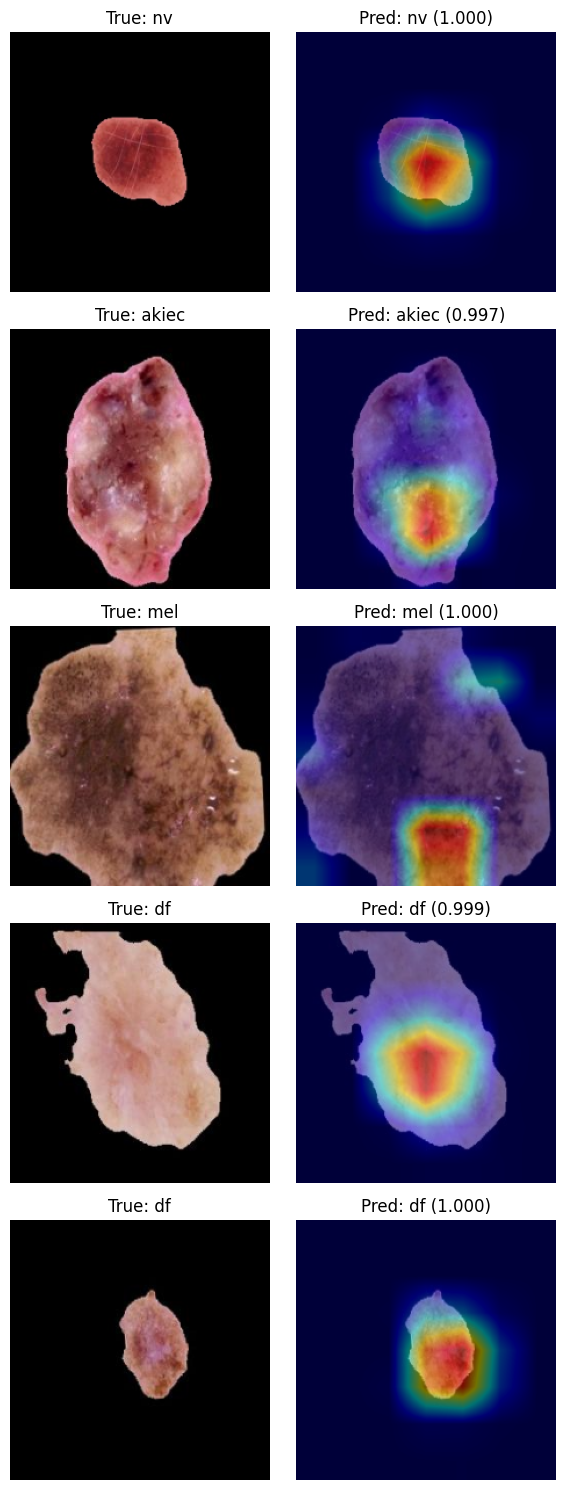

array([1550, 4475, 3271,  584, 4069])

In [44]:
# -----------------------
#  call funtion to view gradcam++ result: 
# -----------------------
show_gradcam_plus_plus(
    model, 
    test_data, 
    labels, 
    n=5,                     # number of images to show
    layer_name=None,         # None = auto-detect last conv layer
    indices=None,            # None = randomly pick images or provide a list
    figsize_per_image=(3,3), # size of each image
    random_seed=42,          # seed for reproducible random selection
)